## Description of Data and Project Introduction

With the recent end of the 2026 Winter Olympics and upcoming Summer Olympics in LA in 2028, we wanted to learn more about the history of the event, including how sports have evolved over time, whether the host country has a "home team advantage," and exploring women's participation and the growth of women's sports

Our data was sourced from kaggle, entitled 120 Years of Olympic History: Athletes and Results and was licensed as public domain. The raw data set contained 15 columns and 172,000 rows with data for each olympic athlete in the "modern Olympic age" - defined as 1896 to present. The data source only contained athlete information through 2016 
<br> https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results

## Imports and Installations

In [41]:
#!pip install plotly seaborn kaleido
#!pip install nbformat --upgrade

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## General Data Cleaing

The data was downloaded and saved as Olympics_data.csv - read into the notebook  below

In [42]:
df = pd.read_csv("Olympics_data.csv")


The medal column contains NaN values for athletes who did not win a medal in their respective event. This data cleaning step differs for later analysis so a user defined function was created to use to prevent manipulating the data to the point it is unusable for further analysis

In [43]:
def clean_medal_column(data):
    """
    Convert medal column to binary:
    1 = Won Medal
    0 = No Medal
    """
    data["Won_Medal"] = np.where(data["Medal"].notna(), 1, 0)
    return data

A host country dictionary was added as only host city is stored as a field in this data set

In [5]:
host_mapping = {
    2016: "BRA",
    2012: "GBR",
    2008: "CHN",
    2004: "GRE",
    2000: "AUS",
    1996: "USA"}

Check to determine the number of null values and columns with null values that will need to be addressed in further analysis

In [6]:
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

## Analysis

### How has women's participation in the Olympics changed over time?

In [24]:
dfq3 = pd.read_csv("Olympics_data.csv")

In [25]:
dfq3["Medal"] = dfq3["Medal"].fillna("No Medal")

#### How has women's participation changed over time?

A deep dive on Olympic gender parity

This code block calculates the percentage of participants made up by women for each Olympic year by creating a new data frame including only each number of unique female athlete IDs for each Olympic year and adding a column for percentage of women the divides the unique number of female IDs for each year by the total number of unique IDs for the year

In [26]:
total = dfq3.groupby('Year')['ID'].nunique()
female = dfq3[dfq3['Sex'] == 'F'].groupby('Year')['ID'].nunique()

female_pct = (female / total * 100).reset_index()
female_pct.columns = ['Year', 'Female_Percent']
female_pct = female_pct.sort_values('Year')

When did women start participating?

In [27]:
womens_dataset = df[df['Sex']=='F']
first_year = womens_dataset['Year'].min()
print("The first year women competed in the Olympics was "+str(first_year))

womens_dataset_winter = womens_dataset[womens_dataset['Season']=='Winter']
first_year_winter = womens_dataset_winter['Year'].min()
print("The first year women competed in the Winter Olympics was "+str(first_year_winter))

The first year women competed in the Olympics was 1900
The first year women competed in the Winter Olympics was 1924


#### Visualization 4

In [28]:
fig, ax = plt.subplots(figsize=(11,6))
plt.close(fig)

ax.set_xlim(female_pct['Year'].min(), female_pct['Year'].max())
ax.set_ylim(0, female_pct['Female_Percent'].max() + 5)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Percent Female Participation", fontsize=12)
ax.set_title("From Exclusion to Inclusion: Women in the Olympic Games",fontsize=14, fontweight='bold')

# Add vertical reference lines
ax.axvline(1900, linestyle='--', color='pink', alpha=0.6)
ax.axvline(1924, linestyle='--', color='pink', alpha=0.6)
ax.axvline(1972, linestyle='--', color='pink', alpha=0.6)

# Add annotations
ax.text(1900, 2,"1900:\nWomen First Allowed to Compete in Summer games",fontsize=10,verticalalignment='bottom')
ax.text(1924, 12,"1924:\nWomen Allowed to Compete in Winter Games",fontsize=10,verticalalignment='bottom')
ax.text(1972, female_pct['Female_Percent'].max() * 0.5,"1972:\nTitle IX Passed\n(U.S. Surge in Women's Sports)",fontsize=10,verticalalignment='bottom')

line, = ax.plot([], [], color="#e622ab", linewidth=3)

# This combined with FuncAnimation() is what essentially created the "drawing" animation as the line is lengthened for each Olympic year and a new data point is added
def update(frame):
    x = female_pct['Year'][:frame]
    y = female_pct['Female_Percent'][:frame]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(
    fig,
    update,
    frames=len(female_pct),
    interval=250,
    repeat=False
)

HTML(ani.to_jshtml())

#### Which major sports are closest to achieving parity?

In [47]:
sport_year_total = dfq3.groupby(['Sport', 'Year'])['ID'].nunique()
sport_year_female = dfq3[dfq3['Sex']=='F'].groupby(['Sport', 'Year'])['ID'].nunique()

sport_year_pct = (sport_year_female / sport_year_total * 100).reset_index()
sport_year_pct.columns = ['Sport', 'Year', 'Female_Percent']

In [48]:
heatmap_data = sport_year_pct.pivot(index='Sport', columns='Year', values='Female_Percent')

# Limit to top 15 sports by participation to keep readable
top_sports = (
    df.groupby('Sport')['ID']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .index)

heatmap_data = heatmap_data.loc[top_sports]

#### Visualization 5

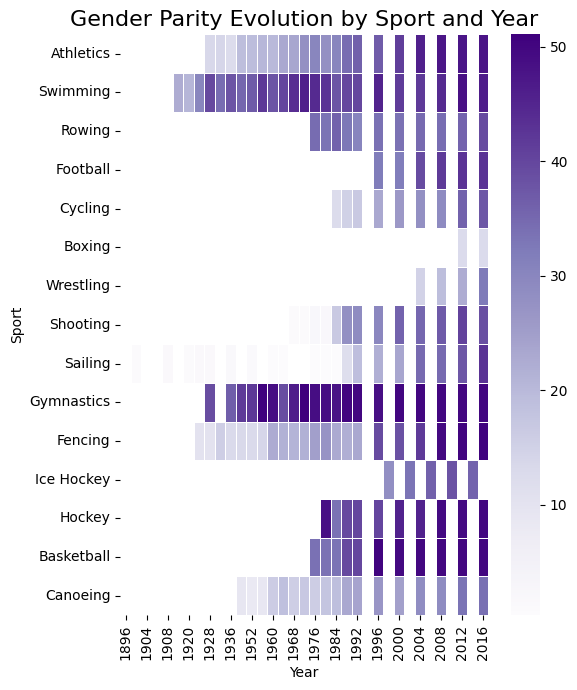

In [49]:
plt.figure(figsize=(6,7))

sns.heatmap(
    heatmap_data,
    cmap="Purples",
    linewidths=0.5,
    linecolor='white')

plt.title("Gender Parity Evolution by Sport and Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()

#### Which countries are closest to achieving gender parity?

In [38]:
country_year_total = dfq3.groupby(['NOC', 'Year'])['ID'].nunique()
country_year_female = dfq3[dfq3['Sex']=='F'].groupby(['NOC', 'Year'])['ID'].nunique()

country_year_pct = (country_year_female / country_year_total * 100).reset_index()
country_year_pct.columns = ['NOC', 'Year', 'Female_Percent']

In [39]:
heatmap_data = country_year_pct.pivot(index='NOC', columns='Year', values='Female_Percent')

# Limit to top 15 countries by participation to keep readable
top_countries = (
    dfq3.groupby('NOC')['ID']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .index)

heatmap_data = heatmap_data.loc[top_countries]
print(heatmap_data)

Year  1896      1900      1904      1906      1908      1912      1920  \
NOC                                                                      
USA    NaN  9.333333  1.145038       NaN       NaN       NaN  4.861111   
GBR    NaN  0.961538       NaN       NaN  5.306122  3.649635  6.837607   
FRA    NaN  1.666667       NaN  1.785714       NaN  0.840336  2.631579   
ITA    NaN  4.347826       NaN       NaN       NaN       NaN  0.574713   
GER    NaN       NaN       NaN       NaN  2.439024  2.702703       NaN   
CAN    NaN       NaN       NaN       NaN       NaN       NaN       NaN   
JPN    NaN       NaN       NaN       NaN       NaN       NaN       NaN   
AUS    NaN       NaN       NaN       NaN       NaN       NaN  7.692308   
SWE    NaN       NaN       NaN       NaN  1.785714  5.180180  5.000000   
POL    NaN       NaN       NaN       NaN       NaN       NaN       NaN   
URS    NaN       NaN       NaN       NaN       NaN       NaN       NaN   
NED    NaN       NaN       NaN       N

#### Visualization 6

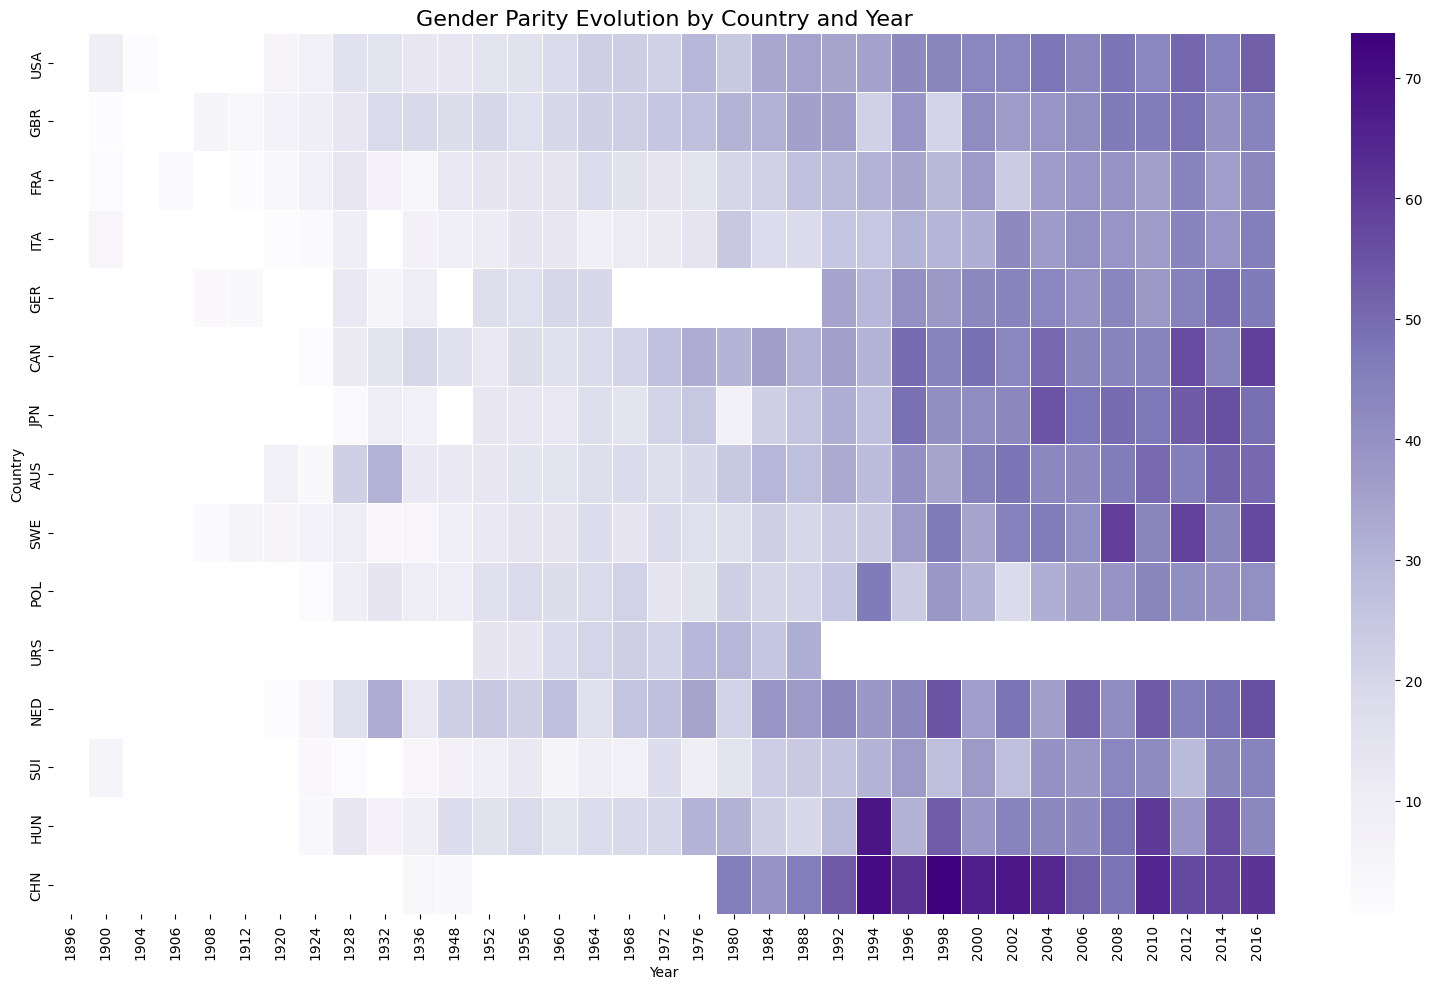

In [40]:
plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_data,
    cmap="Purples",
    linewidths=0.5,
    linecolor='white')

plt.title("Gender Parity Evolution by Country and Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### Findings and conclusions

Although the "modern" Olympics began in 1896, women weren't allowed to compete in the Summer and Winter Olympics until 1900 and 1924 respectively. We saw spikes in those years for women's participation in the Olympics followed by a huge spike in the 1970s, when the US passed TitleIX
<br><br>
When examining the top 15 major sports, there were some surprises on which had more representation. Although athletics (comprised of what many might also refer to as track and field events) started off with low female participation, it is now among the highest. Other sports are less surprising, such as gymnastics which has had high participation levels since women first began competing in 1928.
<br><br>
This led to my final question, which countries are sending higher proportions of women to compete? Although China's female participation began much later than the other top countries, they now lead in participation with a whopping 70% of participants being women. Another notable find is that the United States made a big swing in 1900 with 9% of their athletes comprised of women, with the next highest proportion being Switzerland with 5%.

## Challenges and Learnings

The greatest challenge faced by the team was determining the best way to manipulate a single data source to best fit all of our analytical needs. Although one method of data cleaning worked well for some analytical fact finding, continuing to use the same source throughout the analysis became tricky. Our solution was to create 3 separate dataframes created from the same data source. This allowed each team member to clean and manipulate their dataframe without impact any analysis further down in the notebook. 

The most interesting learning from this project was the flexibility Python has to create a multitude of visuals. The variety and functionality of each visual prompted further thought, deeper analysis, and provided inspiration for other projects.